# Homework 0 - Question 2: Convolution with a Gaussian Kernel and Smoothing

**Full Name:** Farzan Rahmani

**Student ID:** 403210725

---
In this notebook, we will implement and analyze the practical aspects of signal and image smoothing using a Gaussian filter (kernel).

---

# Part (c): 1D Signal Smoothing and Frequency Domain Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

from skimage import data, util
from scipy.fft import fft, fftfreq
from scipy.signal import windows, convolve
from scipy.ndimage import gaussian_filter

### 1. Generating a Noisy Signal

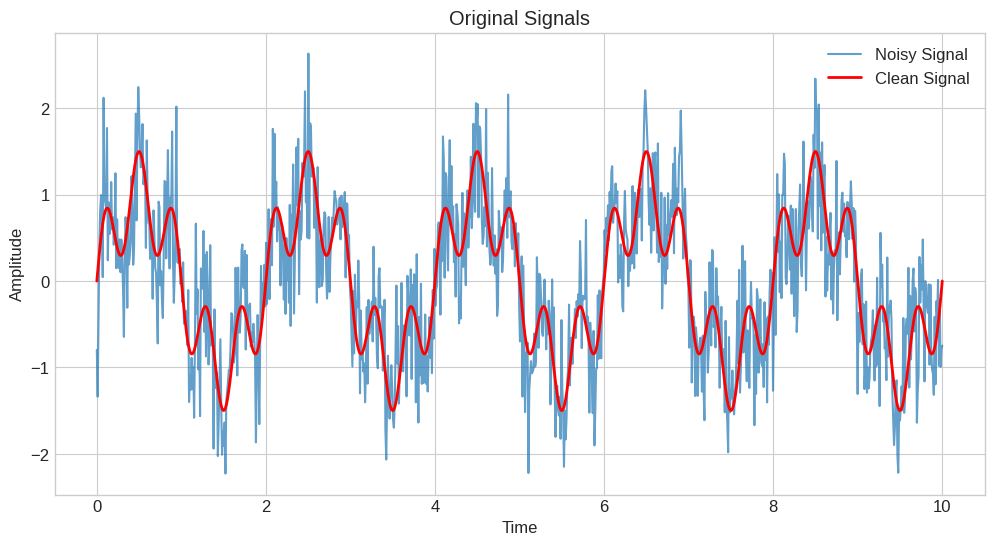

In [2]:
# Plotting style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Signal parameters
n_points = 1000
t = np.linspace(0, 10, n_points)

# Clean signal (combination of two frequencies)
signal_clean = np.sin(2 * np.pi * 0.5 * t) + 0.5 * np.sin(2 * np.pi * 2.5 * t)

# Add Gaussian noise
noise = 0.5 * np.random.randn(n_points)
signal_noisy = signal_clean + noise

# Plot the signals
plt.plot(t, signal_noisy, label='Noisy Signal', alpha=0.7)
plt.plot(t, signal_clean, 'r-', linewidth=2, label='Clean Signal')
plt.title('Original Signals')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

### 2. Smoothing the Signal with Two Different Gaussian Kernels

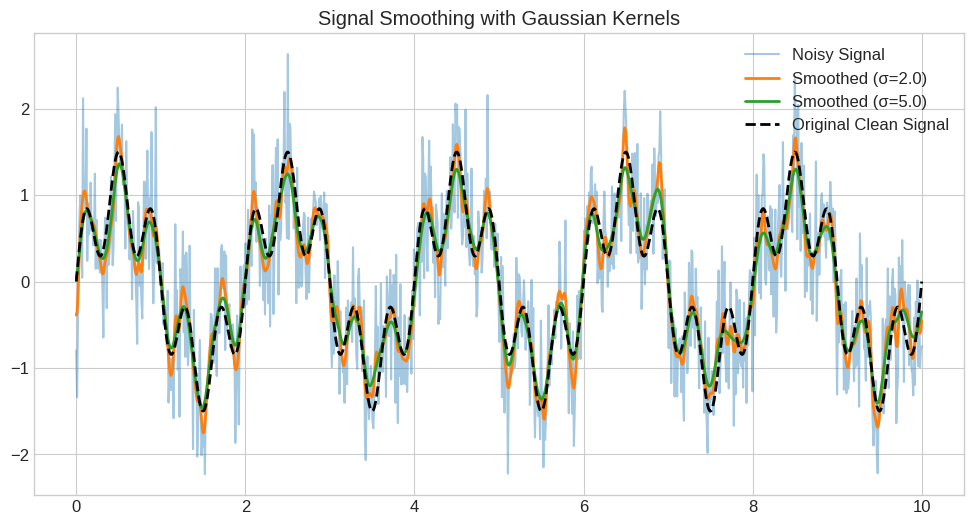

In [3]:
# Create two Gaussian kernels with different standard deviations
# sigma1 = None
# sigma2 = None # Chose a larger second sigma for a more noticeable difference
sigma1 = 2.0
sigma2 = 5.0

M = 51 # Kernel length


# TODO: create two normalized kernels
# Generate the x-axis for the kernel (centered at 0)
x = np.arange(M) - M // 2

# Create Gaussian kernels using the formula: G(x) = (1 / (sqrt(2*pi) * sigma)) * exp(-x^2 / (2*sigma^2))
kernel1 = np.exp(-x**2 / (2 * sigma1**2)) / (np.sqrt(2 * np.pi) * sigma1)
kernel2 = np.exp(-x**2 / (2 * sigma2**2)) / (np.sqrt(2 * np.pi) * sigma2)

# Normalize the kernels so they sum to 1
kernel1 = kernel1 / np.sum(kernel1)
kernel2 = kernel2 / np.sum(kernel2)


# TODO: Convolve the noisy signal with both kernels
# signal_smoothed1 = None
# signal_smoothed2 = None
signal_smoothed1 = convolve(signal_noisy, kernel1, mode='same')
signal_smoothed2 = convolve(signal_noisy, kernel2, mode='same')

# Plot the results
plt.figure()
plt.plot(t, signal_noisy, label='Noisy Signal', alpha=0.4)
plt.plot(t, signal_smoothed1, linewidth=2, label=f'Smoothed (σ={sigma1})')
plt.plot(t, signal_smoothed2, linewidth=2, label=f'Smoothed (σ={sigma2})')
plt.plot(t, signal_clean, 'k--', linewidth=2, label='Original Clean Signal')
plt.title('Signal Smoothing with Gaussian Kernels')
plt.legend()
plt.show()

### 3. Quantitative Error Comparison
In this section, we will numerically check which signal is closer to the original **Clean Signal**.

In [4]:
# Description: Use the 'norm' function to calculate the L2 distance (error) between the signals.

# TODO: Calculate the error of the noisy signal with respect to the clean signal.
# error_noisy = None
error_noisy = norm(signal_clean - signal_noisy)

# TODO: Calculate the error of the two smoothed signals with respect to the clean signal.
# error_smoothed1 = None
# error_smoothed2 = None
error_smoothed1 = norm(signal_clean - signal_smoothed1)
error_smoothed2 = norm(signal_clean - signal_smoothed2)

print(f"Error of Noisy Signal (||S_clean - S_noisy||_2): {error_noisy:.4f}")
print(f"Error of Smoothed Signal (σ={sigma1}) (||S_clean - S_smoothed1||_2): {error_smoothed1:.4f}")
print(f"Error of Smoothed Signal (σ={sigma2}) (||S_clean - S_smoothed2||_2): {error_smoothed2:.4f}")

Error of Noisy Signal (||S_clean - S_noisy||_2): 15.1681
Error of Smoothed Signal (σ=2.0) (||S_clean - S_smoothed1||_2): 5.9284
Error of Smoothed Signal (σ=5.0) (||S_clean - S_smoothed2||_2): 4.5656


### 4. Frequency Domain Analysis

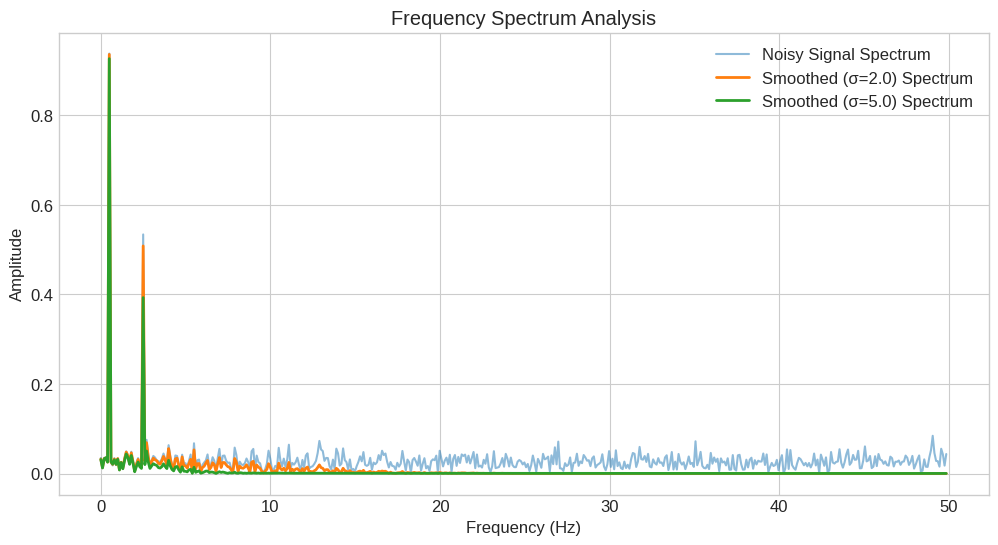

In [5]:
# Compute the Fourier Transform of the signals
yf_noisy = fft(signal_noisy)
yf_smoothed1 = fft(signal_smoothed1)
yf_smoothed2 = fft(signal_smoothed2)

# Compute the frequency axis
xf = fftfreq(n_points, t[1] - t[0])[:n_points//2]

# Plot the frequency spectrum
plt.plot(xf, 2.0/n_points * np.abs(yf_noisy[0:n_points//2]), label='Noisy Signal Spectrum', alpha=0.5)
plt.plot(xf, 2.0/n_points * np.abs(yf_smoothed1[0:n_points//2]), linewidth=2, label=f'Smoothed (σ={sigma1}) Spectrum')
plt.plot(xf, 2.0/n_points * np.abs(yf_smoothed2[0:n_points//2]), linewidth=2, label=f'Smoothed (σ={sigma2}) Spectrum')
plt.title('Frequency Spectrum Analysis')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

### Analysis for Part (c)
**TODO:** Analyze the results. How do the error values calculated in section 3 show that the Gaussian filter succeeded in improving the signal? Explain this improvement using the frequency spectrum plots. Why might a sigma that is too large worsen the result?

1. **Quantitative Error Comparison**:
   - Noisy Signal: ||S_clean - S_noisy||_2 = 15.1681
   - Smoothed with σ=2.0: ||S_clean - S_smoothed1||_2 = 5.9284 (61% reduction in error)
   - Smoothed with σ=5.0: ||S_clean - S_smoothed2||_2 = 4.5656 (70% reduction in error)
   
   Both smoothed signals show dramatically lower errors compared to the noisy signal (lower L2-norm errors), confirming that Gaussian filtering successfully improves signal quality by reducing the distance to the clean signal. Interestingly, σ=5.0 performs better than σ=2.0 in this specific case.

2. **Frequency Domain Explanation**:
   The frequency spectrum plots reveal the mechanism behind this improvement:
   
   - **Signal Frequencies**: The clean signal contains only two frequencies: 0.5 Hz and 2.5 Hz. These appear as the two prominent peaks near 0 Hz in the spectrum.
   
   - **Noise Characteristics**: The noisy signal spectrum (blue) shows elevated amplitude across all frequencies, particularly at higher frequencies. This is typical of Gaussian noise which has a broad frequency distribution.
   
   - **Low-Pass Filtering Effect**: The Gaussian filter acts as a low-pass filter:
     * σ=2.0 (orange): Preserves the signal frequencies (0.5 Hz and 2.5 Hz) while significantly attenuating high-frequency noise
     * σ=5.0 (green): More aggressive attenuation of high frequencies, resulting in even greater noise suppression
   
   - **Why It Works**: Since the noise energy is distributed across all frequencies while the actual signal is concentrated at low frequencies (0.5 Hz and 2.5 Hz), the low-pass filtering preferentially removes noise while preserving the signal components.

3. **Why σ=5.0 (larger sigma) Performed Better in This Case**:
   In this particular example, the larger sigma (5.0) achieved lower error than the smaller sigma (2.0). This occurs because:
   
   - The signal frequencies (0.5 Hz and 2.5 Hz) are very low compared to the noise spectrum
   - Even with σ=5.0, the filter's cutoff frequency is still high enough to preserve these low-frequency signal components
   - The stronger low-pass filtering of σ=5.0 removes more high-frequency noise without significantly attenuating the signal
   - As seen in Images, the σ=5.0 smoothed signal (green) follows the clean signal closely

4. **When Large Sigma Can Worsen Results**:
   However, a sigma that is too large *can* worsen results in other scenarios:
   
   - **Signal-Dependent**: If the clean signal contained higher frequency components (e.g., 10 Hz or 20 Hz), a large sigma would attenuate these legitimate signal frequencies along with the noise
   
   - **Over-Smoothing**: Excessive sigma causes over-smoothing, which:
     * Reduces signal sharpness and transitions
     * Attenuates high-frequency signal content
     * Can introduce phase distortion
     * May increase error if important signal information exists at higher frequencies
   
   - **Frequency Response Trade-off**: A larger sigma corresponds to a narrower pass-band in the frequency domain. If this pass-band becomes narrower than the signal's frequency range, signal distortion occurs.

5. **Conclusion**:
   The optimal sigma depends on the specific signal and noise characteristics:
   - For signals with low-frequency content and high-frequency noise (like this example), larger sigma values can be beneficial
   - For signals with important high-frequency components, smaller sigma values are necessary to avoid signal degradation
   - The key is matching the filter's frequency response to the signal's frequency content while rejecting the noise spectrum


---

# Part (d): Image Smoothing (Denoising) with a Gaussian Filter

### 1. Loading an Image and Adding Noise

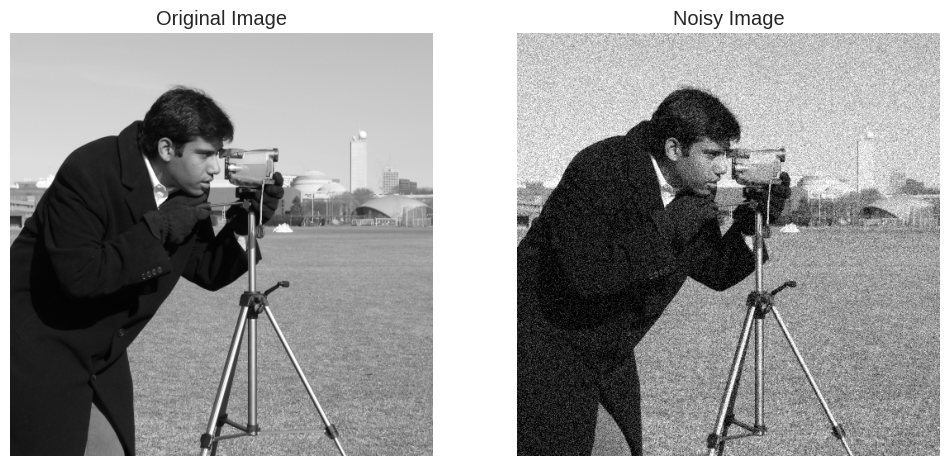

In [6]:
image_original = data.camera().astype(float) / 255.0
image_noisy = util.random_noise(image_original, mode='gaussian', var=0.01)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_original, cmap='gray'); axes[0].set_title('Original Image'); axes[0].axis('off')
axes[1].imshow(image_noisy, cmap='gray'); axes[1].set_title('Noisy Image'); axes[1].axis('off')
plt.show()

### 2. Applying a 2D Gaussian Filter

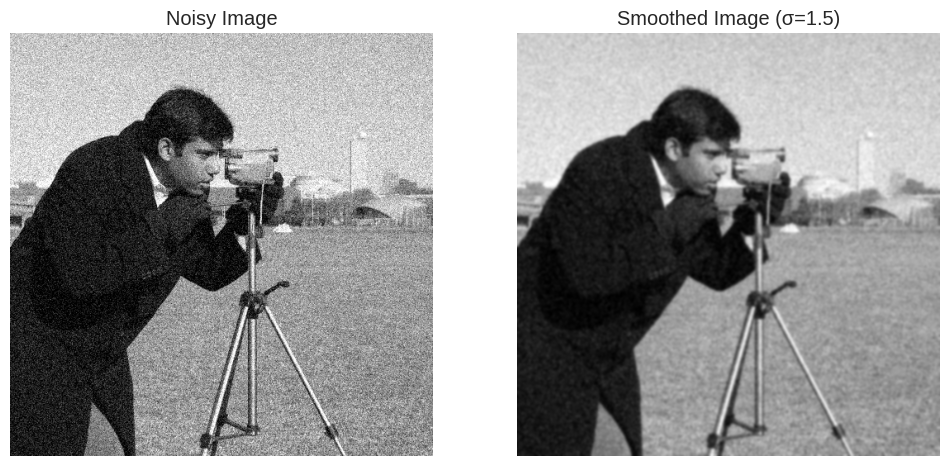

In [7]:
# TODO: Apply the Gaussian filter to the noisy image with a suitable sigma.
# sigma_image = None
# image_smoothed = None
sigma_image = 1.5
image_smoothed = gaussian_filter(image_noisy, sigma=sigma_image)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_noisy, cmap='gray'); axes[0].set_title('Noisy Image'); axes[0].axis('off')
axes[1].imshow(image_smoothed, cmap='gray'); axes[1].set_title(f'Smoothed Image (σ={sigma_image})'); axes[1].axis('off')
plt.show()

### 3. Quantitative Error Comparison
We will numerically check whether the smoothed image is closer to the original image.

In [8]:
# TODO: Calculate the error of the noisy image with respect to the original image.
# error_noisy_img = None
error_noisy_img = norm(image_original - image_noisy)

# TODO: Calculate the error of the smoothed image with respect to the original image.
# error_smoothed_img = None
error_smoothed_img = norm(image_original - image_smoothed)

print(f"Error of Noisy Image (||A_orig - A_noisy||_2): {error_noisy_img:.4f}")
print(f"Error of Smoothed Image (||A_orig - A_smoothed||_2): {error_smoothed_img:.4f}")

Error of Noisy Image (||A_orig - A_noisy||_2): 48.7488
Error of Smoothed Image (||A_orig - A_smoothed||_2): 24.5081


### Analysis for Part (d)
**TODO:** Analyze the result. Do the error values confirm the success of the denoising process? What is the side effect of this process , and where is it most noticeable? Explain the trade-off between noise removal and preserving image details.

**Analysis:**

1. **Quantitative Confirmation of Denoising Success**:
   - Noisy Image Error: ||A_orig - A_noisy||_2 = 48.7488
   - Smoothed Image Error: ||A_orig - A_smoothed||_2 = 24.5081
   - **Error Reduction**: 49.7% reduction in L2-norm error
   
   The error (The L2-norm error) values clearly confirm that the Gaussian filter successfully improved image quality. The smoothed image is significantly closer to the original than the noisy image, demonstrating effective noise removal. The approximately 50% error reduction validates that the denoising process quantitatively recovered substantial information from the noisy image.

2. **Side Effect - Blurring**:
   The primary side effect of Gaussian filtering is blurring, which occurs because the smoothing process:
   - Averages each pixel value with its neighbors in a weighted manner
   - Replaces sharp transitions with gradual gradients
   - Reduces the high-frequency spatial components that create sharp edges and fine details
   - Creates a softer, less crisp overall appearance
   
   This blurring is an inherent consequence of the low-pass filtering nature of the Gaussian kernel in the spatial frequency domain.

3. **Where Blur is Most Noticeable**:
   
   Examining the smoothed image compared to the original, the blur is most prominent in:
   
   - **Sharp Edges**:
     * The tripod legs show reduced sharpness
     * The boundary between the person's silhouette and the background is softer
     * The buildings in the background have less defined edges
   
   - **Fine Details and Textures**:
     * Facial features are less distinct
     * The texture of the person's clothing (suit/jacket) appears smoother
     * Fine structural details of the camera and tripod are less pronounced
     * Grass texture in the foreground is smoothed out
   
   - **High-Contrast Boundaries**:
     * The person's collar and shirt contrast is maintained but with reduced sharpness
     * The separation between the dark suit and lighter background is softened
   
   - **Background Details**:
     * Distant buildings and structures lose fine architectural details
     * The dome structure in the background appears slightly less defined

4. **The Fundamental Trade-off**:
   
   Image denoising presents an inherent trade-off between noise removal and detail preservation:
   
   **Noise Removal Side:**
   - Larger σ → Stronger smoothing → More noise reduction
   - Gaussian noise has high spatial frequency components
   - Low-pass filtering effectively attenuates these high frequencies
   - Results in cleaner-looking images with reduced graininess
   
   **Detail Preservation Side:**
   - Important image features (edges, textures) also contain high frequencies
   - Larger σ → More aggressive filtering → Greater detail loss
   - Small σ → Preserves more details but removes less noise
   - Fine details and sharp transitions are sacrificed for smoothness
   
   **The Balancing Act:**
   - σ = 1.5 was chosen as a moderate value for this image
   - Too small: Insufficient noise removal, image remains grainy
   - Too large: Over-smoothing, loss of important visual information
   - Optimal σ depends on:
     * Noise level (variance of added noise)
     * Image content (how much fine detail is present)
     * Application requirements (whether sharpness or smoothness is prioritized)

5. **Theoretical Expectation vs. Practical Results**:
   
   **Why the smoothed image has lower error in this case:**
   - The added Gaussian noise (variance = 0.01) is purely high-frequency random variation
   - The original image's important information is primarily in low-to-mid frequencies
   - The Gaussian filter preferentially removes the noise frequencies while preserving most structural information
   - The noise component contributes more to the error than the slight blur introduced by filtering
   
   **When this might not hold:**
   - If σ is too large, over-smoothing can destroy important image features
   - The error could increase if critical edges or textures are excessively blurred
   - For images with very fine details (e.g., text, intricate patterns), even moderate smoothing can increase error
   - The optimal denoising depends on the signal-to-noise ratio and the spatial frequency distribution of the image content
   
   **Conclusion:**
   The Gaussian filter with σ = 1.5 achieves a good balance for this image, reducing error by approximately 50% while maintaining recognizable image structure. However, visual inspection reveals the cost: reduced sharpness and detail. In practical applications, the choice of σ must consider both quantitative metrics (error) and qualitative factors (perceived image quality, intended use).